<a href="https://colab.research.google.com/github/tacyataide/Revisao/blob/main/Mouse_e_Trackbar_na_GUI_do_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Eventos do Mouse no OpenCV

Os eventos do mouse permitem detectar cliques e posições do cursor sobre uma imagem. Neste exemplo, usamos o mouse para selecionar uma região e desenhar um retângulo.

Como o Google Colab não suporta cv2.namedWindow() e cv2.setMouseCallback(), podemos fazer essa interação usando o Matplotlib.

In [3]:
!pip install ipympl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 115.4 MB/s eta 0:00:00


Saving input_image-2.jpg to input_image-2 (5).jpg


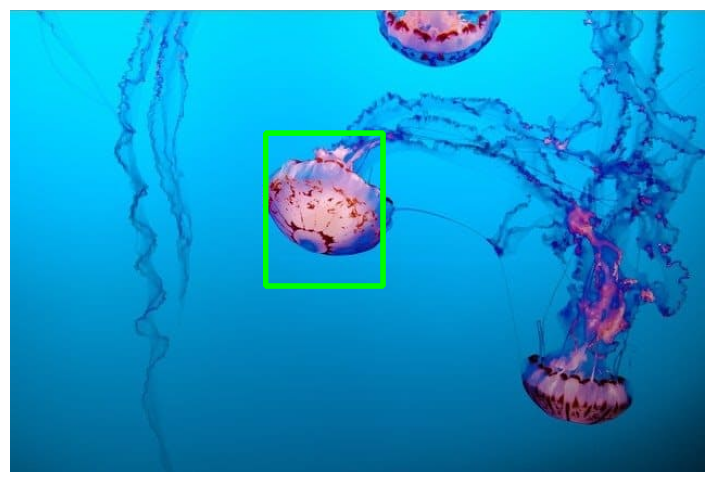

In [13]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

nome = list(uploaded.keys())[0]
img = cv2.imread(nome)

x1, y1 = 235, 113
x2, y2 = 343, 254

resultado = img.copy()

cv2.rectangle(resultado, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Redimensionando uma Imagem

O redimensionamento permite aumentar ou diminuir o tamanho de uma imagem. Como a barra de rolagem do cv2.createTrackbar() não funciona diretamente no Google Colab, podemos usar um controle deslizante próprio do notebook para obter o mesmo resultado.

O valor da barra define a porcentagem de aumento da imagem.

In [16]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, clear_output

uploaded = files.upload()

nome = list(uploaded.keys())[0]
img = cv2.imread(nome)

barra = widgets.IntSlider(
    value=0,
    min=0,
    max=100,
    step=1,
    description='Scale:',
    continuous_update=True
)

saida = widgets.Output()

def redimensionar(change):
    escala = 1 + change['new'] / 100.0

    imagem = cv2.resize(
        img,
        None,
        fx=escala,
        fy=escala,
        interpolation=cv2.INTER_LINEAR
    )

    altura, largura = imagem.shape[:2]

    with saida:
        clear_output(wait=True)

        plt.figure(figsize=(largura / 100, altura / 100))
        plt.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

barra.observe(redimensionar, names='value')

display(barra)
display(saida)

redimensionar({'new': barra.value})

Saving input_image-2.jpg to input_image-2 (8).jpg


IntSlider(value=0, description='Scale:')

Output()